A9.7 Estimation of a vector from one-bit measurements
Part (b)

In [1]:
import os
import sys

# add the directory containing the notebook to Python path
sys.path.append(os.getcwd())

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

iter  0: f = 24.4363126467, lambda^2/2 = 3.324e+00
iter  1: f = 20.4524981744, lambda^2/2 = 8.421e-01
iter  2: f = 19.4247833134, lambda^2/2 = 1.214e-01
iter  3: f = 19.3007317482, lambda^2/2 = 2.035e-04
iter  4: f = 19.3005278780, lambda^2/2 = 1.956e-09

ML estimate x_hat:
[-0.27067603  9.1484533   7.97861969  6.70346046  6.02665445  5.01204115
  4.29979745  2.67648277  2.02078954  0.68378372]


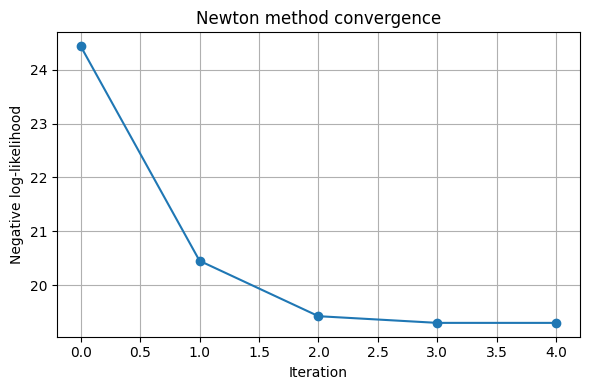

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcx

import one_bit_meas_data as data

A = np.array(data.A, dtype=float)
b = np.array(data.b, dtype=float).flatten()
y = np.array(data.y, dtype=float).flatten()

m, n = A.shape


def log_Phi(u):

    out = np.empty_like(u)
    idx = (u < 0)

    # For u < 0
    out[idx] = np.log(0.5 * erfcx(-u[idx] / np.sqrt(2.0))) - 0.5 * u[idx]**2

    # For u >= 0
    out[~idx] = np.log(0.5 * erfc(-u[~idx] / np.sqrt(2.0)))

    return out

def mills_ratio(u):
    return np.sqrt(2.0 / np.pi) / erfcx(-u / np.sqrt(2.0))

def f_grad_hess(x):

    u = y * (A @ x - b)               

    #f(x) = -sum log Phi(u_i)
    f = -np.sum(log_Phi(u))

    lam = mills_ratio(u)               

    # grad f = - A^T ( y .* lambda )
    grad = -A.T @ (y * lam)

    # Hessian of negative log-likelihood
    d = lam * (u + lam)
    hess = A.T @ (d[:, None] * A)

    return f, grad, hess

x = np.linalg.lstsq(A, b, rcond=None)[0]

alpha = 0.25
beta = 0.5
tol = 1e-8
max_iter = 50

history = []

for k in range(max_iter):
    f, g, H = f_grad_hess(x)

    # Newton step
    dx = -np.linalg.solve(H, g)
    lambda_sq = -g @ dx
    history.append(f)

    print(f"iter {k:2d}: f = {f:.10f}, lambda^2/2 = {lambda_sq/2:.3e}")

    if lambda_sq / 2 <= tol:
        break

    t = 1.0
    while True:
        x_new = x + t * dx
        f_new, _, _ = f_grad_hess(x_new)
        if f_new <= f + alpha * t * (g @ dx):
            break
        t *= beta

    x = x_new

x_ml = x
print("\nML estimate x_hat:")
print(x_ml)

plt.figure(figsize=(6,4))
plt.plot(history, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Negative log-likelihood")
plt.title("Newton method convergence")
plt.grid(True)
plt.tight_layout()
plt.show()